In [1]:
import torch
from torch import nn
import pandas as pd
import sys
from pathlib import Path

train_labels = pd.read_csv('../cifar-10/trainLabels.csv')
val_labels = pd.read_csv('../cifar-10/valLabels.csv')

sys.path.append(str(Path.cwd().parent))
torch.manual_seed(42)

In [2]:
from src.dataset import CIFAR10Dataset, train_transforms, val_transforms

train_dataset = CIFAR10Dataset(
    image_dir='../cifar-10/train',
    labels=train_labels,
    transform=train_transforms
)

val_dataset = CIFAR10Dataset(
    image_dir='../cifar-10/val',
    labels=val_labels,
    transform=val_transforms
)

In [3]:
from src.dataset import create_dataloader

train_loader = create_dataloader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = create_dataloader(
    dataset=val_dataset,
    batch_size=32,
    shuffle=False
)

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [5]:
from src.models import CIFARDeeperCNN
from src.metrics import create_metrics
from src.engine import fit

model = CIFARDeeperCNN().to(device)

train_metrics = create_metrics(num_classes=10)
val_metrics = create_metrics(num_classes=10)

for metric in train_metrics.values():
    metric = metric.to(device)
for metric in val_metrics.values():
    metric = metric.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)
epochs = 30

history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_metrics=train_metrics,
    val_metrics=val_metrics,
    epochs=epochs,
    device=device,
    file_path='../models/CIFAR_Augmentation_WD_DeeperCNN.pt'
)

history


Epoch 1/30:
Training Loss: 1.8378 | Training Accuracy: 30.81% | Training Precision: 30.15% | Training Recall: 30.81%
Validation Loss: 1.5939 | Validation Accuracy: 40.66% | Validation Precision: 41.31% | Validation Recall: 40.66%
Best model saved! Val Acc: 40.66%

Epoch 2/30:
Training Loss: 1.5312 | Training Accuracy: 43.48% | Training Precision: 42.76% | Training Recall: 43.48%
Validation Loss: 1.4445 | Validation Accuracy: 47.26% | Validation Precision: 49.81% | Validation Recall: 47.26%
Best model saved! Val Acc: 47.26%

Epoch 3/30:
Training Loss: 1.3627 | Training Accuracy: 50.15% | Training Precision: 49.44% | Training Recall: 50.15%
Validation Loss: 1.2132 | Validation Accuracy: 55.98% | Validation Precision: 56.89% | Validation Recall: 55.98%
Best model saved! Val Acc: 55.98%

Epoch 4/30:
Training Loss: 1.2372 | Training Accuracy: 55.13% | Training Precision: 54.53% | Training Recall: 55.13%
Validation Loss: 1.1573 | Validation Accuracy: 58.52% | Validation Precision: 61.30% | 

,epoch,train_loss,train_accuracy,train_precision,train_recall,val_loss,val_accuracy,val_precision,val_recall
0,1,1.837812,0.308075,0.301543,0.308075,1.593945,0.4066,0.413142,0.4066
1,2,1.531200,0.434775,0.427558,0.434775,1.444467,0.4726,0.498099,0.4726
2,3,1.362747,0.501525,0.494420,0.501525,1.213180,0.5598,0.568876,0.5598
3,4,1.237187,0.551300,0.545348,0.551300,1.157250,0.5852,0.612996,0.5852
4,5,1.151013,0.584000,0.579625,0.584000,1.048148,0.6242,0.623815,0.6242
5,6,1.071024,0.613575,0.609976,0.613575,0.982359,0.6530,0.662822,0.6530
6,7,1.006828,0.640325,0.637159,0.640325,0.954084,0.6636,0.674404,0.6636
7,8,0.954497,0.662100,0.659566,0.662100,0.885427,0.6800,0.705126,0.6800
8,9,0.910968,0.675425,0.672958,0.675425,0.857047,0.6880,0.697856,0.6880
9,10,0.872299,0.690500,0.688506,0.690500,0.879871,0.6918,0.710561,0.6918


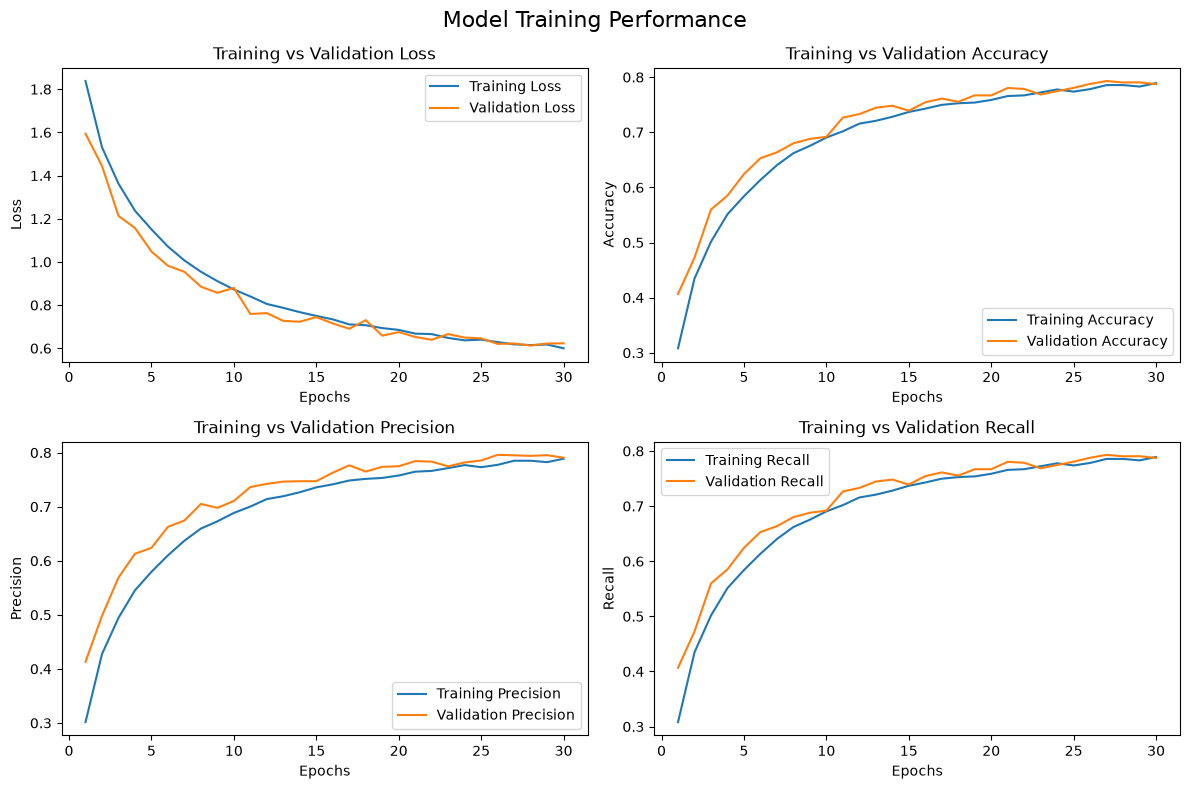

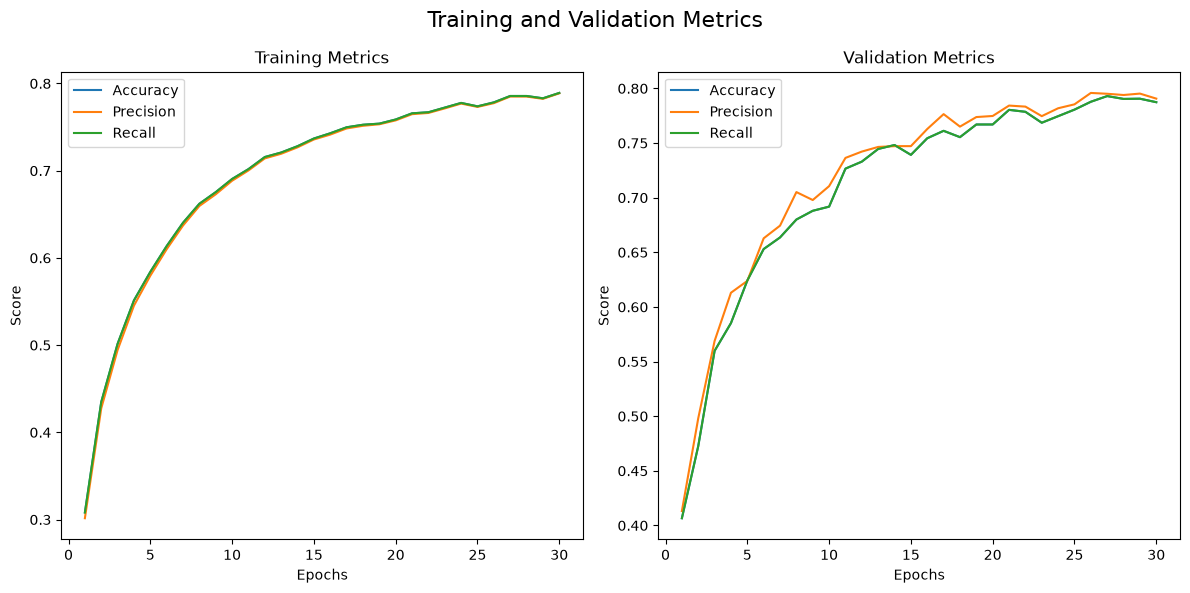

In [6]:
from src.plots import plot_all_metrics, plot_performance

plot_all_metrics(history=history)
plot_performance(history=history)

In [7]:
from src.models import CIFARFeatureCNN
from src.metrics import create_metrics
from src.engine import fit

exp = CIFARFeatureCNN().to(device)

train_metrics = create_metrics(num_classes=10)
val_metrics = create_metrics(num_classes=10)

for metric in train_metrics.values():
    metric = metric.to(device)
for metric in val_metrics.values():
    metric = metric.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=exp.parameters(),
    lr=0.001,
    weight_decay=1e-4
)
epochs = 30

history = fit(
    model=exp,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_metrics=train_metrics,
    val_metrics=val_metrics,
    epochs=epochs,
    device=device,
    file_path='../models/CIFAR_Augmentation_WD_FeatureCNN.pt'
)

history


Epoch 1/30:
Training Loss: 1.7735 | Training Accuracy: 34.17% | Training Precision: 33.72% | Training Recall: 34.17%
Validation Loss: 1.4714 | Validation Accuracy: 45.02% | Validation Precision: 46.29% | Validation Recall: 45.02%
Best model saved! Val Acc: 45.02%

Epoch 2/30:
Training Loss: 1.3986 | Training Accuracy: 48.87% | Training Precision: 48.25% | Training Recall: 48.87%
Validation Loss: 1.1692 | Validation Accuracy: 58.24% | Validation Precision: 59.82% | Validation Recall: 58.24%
Best model saved! Val Acc: 58.24%

Epoch 3/30:
Training Loss: 1.1472 | Training Accuracy: 58.66% | Training Precision: 58.24% | Training Recall: 58.66%
Validation Loss: 0.9592 | Validation Accuracy: 66.52% | Validation Precision: 67.26% | Validation Recall: 66.52%
Best model saved! Val Acc: 66.52%

Epoch 4/30:
Training Loss: 0.9916 | Training Accuracy: 64.46% | Training Precision: 64.19% | Training Recall: 64.46%
Validation Loss: 0.8761 | Validation Accuracy: 68.94% | Validation Precision: 70.04% | 

,epoch,train_loss,train_accuracy,train_precision,train_recall,val_loss,val_accuracy,val_precision,val_recall
0,1,1.773482,0.341700,0.337236,0.341700,1.471366,0.4502,0.462917,0.4502
1,2,1.398557,0.488675,0.482457,0.488675,1.169237,0.5824,0.598151,0.5824
2,3,1.147243,0.586575,0.582406,0.586575,0.959196,0.6652,0.672608,0.6652
3,4,0.991573,0.644625,0.641870,0.644625,0.876138,0.6894,0.700413,0.6894
4,5,0.874508,0.691725,0.689918,0.691725,0.816302,0.7102,0.732904,0.7102
5,6,0.804756,0.716975,0.715781,0.716975,0.817748,0.7102,0.734124,0.7102
6,7,0.749759,0.737000,0.736142,0.737000,0.689334,0.7592,0.770222,0.7592
7,8,0.712479,0.751425,0.750498,0.751425,0.668555,0.7706,0.774424,0.7706
8,9,0.675681,0.762825,0.762107,0.762825,0.613567,0.7872,0.792209,0.7872
9,10,0.653315,0.773825,0.772980,0.773825,0.653028,0.7752,0.778690,0.7752


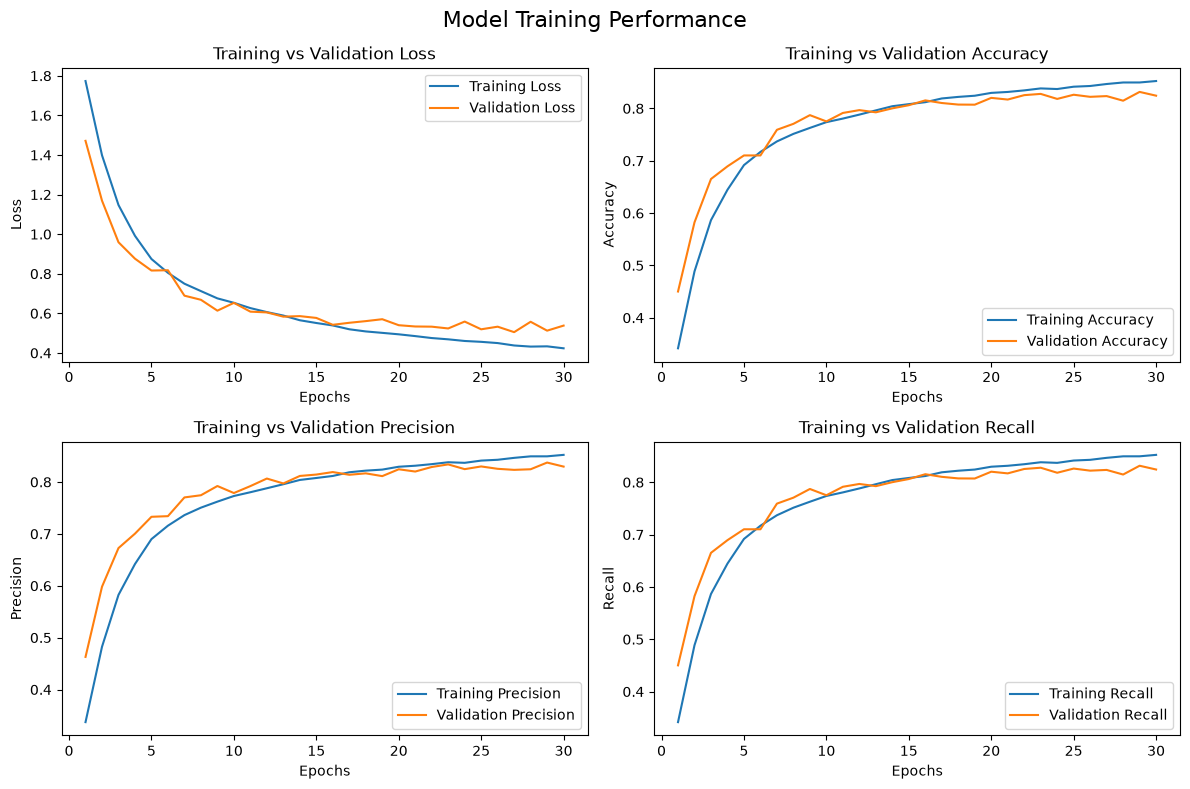

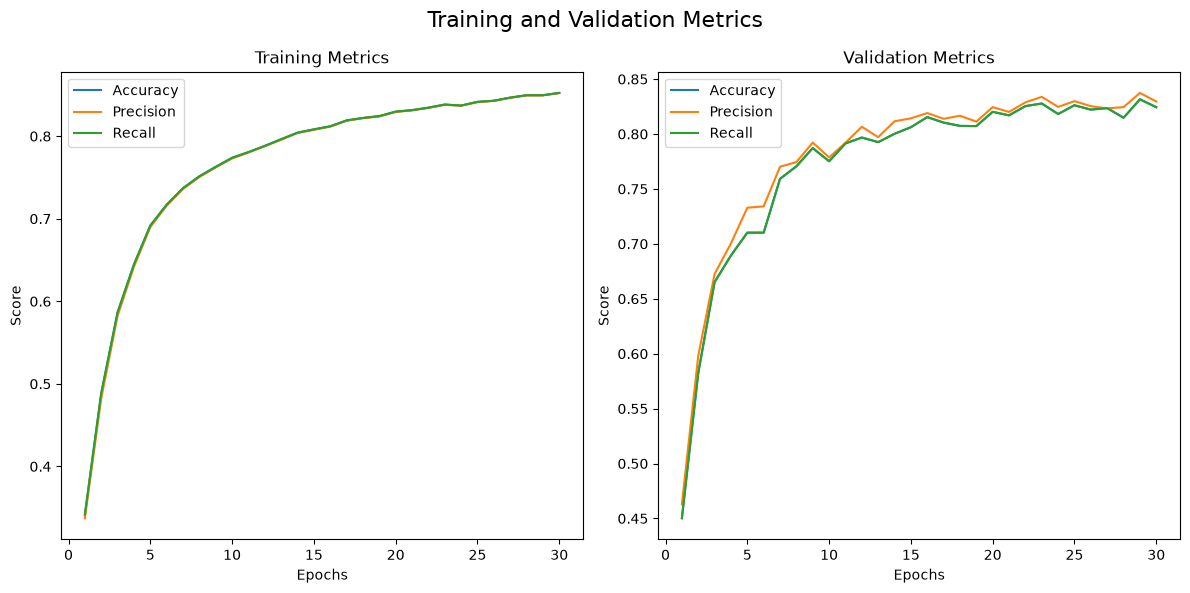

In [8]:
from src.plots import plot_all_metrics, plot_performance

plot_all_metrics(history=history)
plot_performance(history=history)